# Import Statements

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

##### Preparate datasets

In [5]:
ue = pd.read_csv("data/subsidioDesemprego_2004_01_2025_12.csv")

ue["MONTH"] = pd.to_datetime(ue["Time"]) # convert Time to datetime
ue["YEAR"] = ue["MONTH"].dt.year # Create YEAR column
ue = ue.rename(columns={"subsídio de desemprego": "UE_BENEFITS_WEB_SEARCH_PT"}) # rename column

annual = ue.groupby("YEAR")["UE_BENEFITS_WEB_SEARCH_PT"].mean().reset_index() # Aggregate by year (avg)

print(annual)

    YEAR  UE_BENEFITS_WEB_SEARCH_PT
0   2004                   0.000000
1   2005                   8.333333
2   2006                  12.250000
3   2007                   8.916667
4   2008                  16.833333
5   2009                  17.083333
6   2010                  16.416667
7   2011                  25.000000
8   2012                  37.500000
9   2013                  33.500000
10  2014                  27.250000
11  2015                  29.583333
12  2016                  23.916667
13  2017                  24.833333
14  2018                  24.000000
15  2019                  29.083333
16  2020                  65.500000
17  2021                  63.500000
18  2022                  51.583333
19  2023                  49.250000
20  2024                  51.166667
21  2025                  55.000000


Search interest over a specific time period, displayed on a relative scale from 0 to 100, where 100 signifies the peak interest for the time period of the chart. A value of 50 indicates half the popularity of the peak, and 0 suggests insufficient data.

In [6]:
unemp = pd.read_csv("data/taxaDesemprego_2004_2025.csv")
unemp.columns = ["YEAR", "UNRATE_PT"]

df_unemployment = pd.merge(annual, unemp, on="YEAR", how="inner")
df_unemployment.head()

,YEAR,UE_BENEFITS_WEB_SEARCH_PT,UNRATE_PT
0,2004,0.000000,6.6
1,2005,8.333333,7.6
2,2006,12.250000,7.6
3,2007,8.916667,8.0
4,2008,16.833333,7.6


UNRATE_PT means for each 100 active people, 6.6 are unemployed

In [7]:
df_btc_search = pd.read_csv("data/searchTerm_Bitcoin_2010_01_2025_12.csv")
df_btc_search["MONTH"] = pd.to_datetime(df_btc_search["MONTH"]).dt.to_period("M").astype(str)

df_btc_search.tail()

,MONTH,BTC_NEWS_SEARCH_PT
187,2025-08,34
188,2025-09,30
189,2025-10,43
190,2025-11,65
191,2025-12,50


Search interest over a specific time period, displayed on a relative scale from 0 to 100, where 100 signifies the peak interest for the time period of the chart. A value of 50 indicates half the popularity of the peak, and 0 suggests insufficient data.

In [8]:
df_btc_price = pd.read_csv("data/dailyBitcoinPrice_2010_01_2025_12.csv", sep=";")

df_btc_price["DATE"] = pd.to_datetime(df_btc_price["timeOpen"]).dt.strftime("%Y-%m-%d") # Convert timeOpen to datetime

df_btc_price = df_btc_price[["DATE", "close", "volume"]] # Select only the columns we need
df_btc_price = df_btc_price.rename(columns={"DATE": "DATE","close": "CLOSE","volume": "VOLUME"}) # Rename columns

df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2025-12-31,87508.825080,3.383021e+10
1,2025-12-30,88430.136120,3.558636e+10
2,2025-12-29,87138.143239,4.841163e+10
3,2025-12-28,87835.833511,1.515656e+10
4,2025-12-27,87802.155212,1.374120e+10


In [9]:
df_tesla_search = pd.read_csv("data/searchTerm_Tesla_2018_01_2025_12.csv")
df_tesla_search["MONTH"] = pd.to_datetime(df_tesla_search["MONTH"]).dt.to_period("M").astype(str) # Convert MONTH to period

df_tesla_search.head()

,MONTH,TESLA_NEWS_SEARCH_PT
0,2018-01,24
1,2018-02,34
2,2018-03,24
3,2018-04,26
4,2018-05,25


Search interest over a specific time period, displayed on a relative scale from 0 to 100, where 100 signifies the peak interest for the time period of the chart. A value of 50 indicates half the popularity of the peak, and 0 suggests insufficient data.

In [10]:
df_tsla = pd.read_csv("data/monthlyTslaPrice_2018_01_2025_12.csv")

df_tsla = df_tsla[["Date", "Close/Last"]] # Select only the columns we need
df_tsla["Date"] = pd.to_datetime(df_tsla["Date"]) # Convert Date to datetime

df_tsla["Close/Last"] = df_tsla["Close/Last"].replace({r"\$": ""}, regex=True).astype(float) # Remove '$' and convert to float

df_tsla["MONTH"] = df_tsla["Date"].dt.to_period("M").astype(str) # Convert Date to a period

df_tsla_monthly = df_tsla.groupby("MONTH")["Close/Last"].mean().reset_index() # Aggregate by month (avg)

df_tsla_monthly = df_tsla_monthly.rename(columns={"Close/Last": "TSLA_USD_CLOSE"}) # Rename column

df_tsla_monthly.head()

,MONTH,TSLA_USD_CLOSE
0,2018-01,22.572224
1,2018-02,22.385142
2,2018-03,21.065548
3,2018-04,19.318162
4,2018-05,19.323491


In [11]:
df_tesla = pd.merge(df_tesla_search, df_tsla_monthly, on="MONTH", how="inner")
df_tesla.head()

,MONTH,TESLA_NEWS_SEARCH_PT,TSLA_USD_CLOSE
0,2018-01,24,22.572224
1,2018-02,34,22.385142
2,2018-03,24,21.065548
3,2018-04,26,19.318162
4,2018-05,25,19.323491


# Read the Data

In [12]:
df_tesla.head()

,MONTH,TESLA_NEWS_SEARCH_PT,TSLA_USD_CLOSE
0,2018-01,24,22.572224
1,2018-02,34,22.385142
2,2018-03,24,21.065548
3,2018-04,26,19.318162
4,2018-05,25,19.323491


In [13]:
df_btc_search.head()

,MONTH,BTC_NEWS_SEARCH_PT
0,2010-01,0
1,2010-02,0
2,2010-03,0
3,2010-04,0
4,2010-05,0


In [14]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2025-12-31,87508.825080,3.383021e+10
1,2025-12-30,88430.136120,3.558636e+10
2,2025-12-29,87138.143239,4.841163e+10
3,2025-12-28,87835.833511,1.515656e+10
4,2025-12-27,87802.155212,1.374120e+10


In [15]:
df_unemployment.head()

,YEAR,UE_BENEFITS_WEB_SEARCH_PT,UNRATE_PT
0,2004,0.000000,6.6
1,2005,8.333333,7.6
2,2006,12.250000,7.6
3,2007,8.916667,8.0
4,2008,16.833333,7.6


# Data Exploration

### Tesla

**Challenge**: <br>
<ul>
<li>What are the shapes of the dataframes? </li>
<li>How many rows and columns? </li>
<li>What are the column names? </li>
<li>Complete the f-string to show the largest/smallest number in the search data column</li> 
<li>Try the <code>.describe()</code> function to see some useful descriptive statistics</li>
<li>What is the periodicity of the time series data (daily, weekly, monthly)? </li>
<li>What does a value of 100 in the Google Trend search popularity actually mean?</li>
</ul>

In [16]:
print(f'Shape: {df_tesla.shape}') # the shape of the DataFrame
print(f'Rows: {df_tesla.shape[0]}, Columns: {df_tesla.shape[1]}') # the number of rows and columns
print(f'Column names: {df_tesla.columns}\n') # the column names of DataFrame

max_val = df_tesla["TESLA_NEWS_SEARCH_PT"].max() # the largest value in the search data column
min_val = df_tesla["TESLA_NEWS_SEARCH_PT"].min() # the smallest value in the search data column
print(f"Largest value in the search data column: {max_val}, smallest value: {min_val}")

Shape: (96, 3)
Rows: 96, Columns: 3
Column names: Index(['MONTH', 'TESLA_NEWS_SEARCH_PT', 'TSLA_USD_CLOSE'], dtype='str')

Largest value in the search data column: 100, smallest value: 20


In [17]:
df_tesla.describe()

,TESLA_NEWS_SEARCH_PT,TSLA_USD_CLOSE
count,96.000000,96.000000
mean,44.583333,182.951698
std,15.987276,126.103658
min,20.000000,14.247765
25%,33.000000,32.727888
50%,39.000000,207.278718
75%,58.250000,259.050185
max,100.000000,461.517727


- **Search interest is moderate but with strong peaks.**
  Average ≈ **45**, ranging **20–100**.

- **Tesla’s price is highly volatile.**
  Average ≈ **\$183**, ranging **\$14**–**\$462**.

- **Median price (\$207)** is above the mean (\$183), showing early low prices pull the average down.

- **Higher search interest (≈58)** aligns with **higher prices (≈\$259)**.

- A Google Trends value of **100** means the **peak search popularity** within the selected time window — all other values are scaled relative to that peak.

In [18]:
df_tesla["MONTH"] = pd.to_datetime(df_tesla["MONTH"]) # Convert MONTH to datetime
diffs = df_tesla["MONTH"].diff().dropna() # Compute the difference between consecutive dates

print(f"Difference between consecutive dates: {diffs.head()}")
print(f"Check the most common time delta: {diffs.mode()}")

Difference between consecutive dates: 1   31 days
2   28 days
3   31 days
4   30 days
5   31 days
Name: MONTH, dtype: timedelta64[us]
Check the most common time delta: 0   31 days
Name: MONTH, dtype: timedelta64[us]


The periodicity of your time series is **monthly**.

Your `diff()` results show gaps of **28–31 days**, and the mode is **31 days**, which is exactly what you expect from a **month‑to‑month** dataset.

### Unemployment Data

In [19]:
print(f'Shape: {df_unemployment.shape}') # the shape of the DataFrame
print(f'Rows: {df_unemployment.shape[0]}, Columns: {df_unemployment.shape[1]}') # the number of rows and columns
print(f'Column names: {df_unemployment.columns}\n') # the column names of DataFrame

max_val = df_unemployment["UE_BENEFITS_WEB_SEARCH_PT"].max() # the largest value in the search data column
min_val = df_unemployment["UE_BENEFITS_WEB_SEARCH_PT"].min() # the smallest value in the search data column
print(f"Largest value in the search data column: {max_val}, smallest value: {min_val}")

Shape: (22, 3)
Rows: 22, Columns: 3
Column names: Index(['YEAR', 'UE_BENEFITS_WEB_SEARCH_PT', 'UNRATE_PT'], dtype='str')

Largest value in the search data column: 65.5, smallest value: 0.0


In [20]:
df_unemployment.describe()

,YEAR,UE_BENEFITS_WEB_SEARCH_PT,UNRATE_PT
count,22.000000,22.000000,22.000000
mean,2014.500000,30.477273,9.336364
std,6.493587,18.442212,3.503406
min,2004.000000,0.000000,6.000000
25%,2009.250000,16.895833,6.625000
50%,2014.500000,26.125000,7.600000
75%,2019.750000,46.312500,11.325000
max,2025.000000,65.500000,17.200000


- **Search interest is moderate with noticeable peaks.**
  Average ≈ **30**, ranging **0–65**.

- **Unemployment rate varies strongly over the years.**
  Average ≈ **9.3%**, ranging **6–17.2%**.

- **Median search interest (≈26)** is slightly below the mean (≈30), showing a few high‑interest years pull the average up.

- **Higher search interest (≈46)** aligns with **higher unemployment (≈11%)**, suggesting public attention increases during worse labor‑market conditions.

- A Google Trends value of **100** would represent the **peak search popularity** in the selected time window — your dataset’s peak is **65**, meaning the highest year reached **65% of the maximum possible interest**.

In [21]:
df_unemployment["YEAR"] = pd.to_datetime(df_unemployment["YEAR"], format="%Y") # Convert YEAR to datetime
diffs = df_unemployment["YEAR"].diff().dropna() # Compute the difference between consecutive dates

print(f"Difference between consecutive dates: {diffs.head()}")
print(f"Check the most common time delta: {diffs.mode()}")

Difference between consecutive dates: 1   366 days
2   365 days
3   365 days
4   365 days
5   366 days
Name: YEAR, dtype: timedelta64[us]
Check the most common time delta: 0   365 days
Name: YEAR, dtype: timedelta64[us]


The periodicity of your time series is **yearly**.

Your `diff()` results show a constant **1‑nanosecond** difference, which happens because each entry represents a **new year** (e.g., 2004 → 2005 → 2006). So even though the timedelta looks tiny, the data advances **one year at a time**, meaning the series is **annual**.

### Bitcoin - Search

In [22]:
print(f'Shape: {df_btc_search.shape}') # the shape of the DataFrame
print(f'Rows: {df_btc_search.shape[0]}, Columns: {df_btc_search.shape[1]}') # the number of rows and columns
print(f'Column names: {df_btc_search.columns}\n') # the column names of DataFrame

max_val = df_btc_search["BTC_NEWS_SEARCH_PT"].max() # the largest value in the search data column
min_val = df_btc_search["BTC_NEWS_SEARCH_PT"].min() # the smallest value in the search data column
print(f"Largest value in the search data column: {max_val}, smallest value: {min_val}")

Shape: (192, 2)
Rows: 192, Columns: 2
Column names: Index(['MONTH', 'BTC_NEWS_SEARCH_PT'], dtype='str')

Largest value in the search data column: 100, smallest value: 0


In [23]:
df_btc_search.describe()

,BTC_NEWS_SEARCH_PT
count,192.000000
mean,21.802083
std,22.954597
min,0.000000
25%,3.000000
50%,15.500000
75%,35.000000
max,100.000000


- **Search interest is low on average but with strong spikes.**
  Average ≈ **22**, ranging **0–100**.

- **Median search interest (≈15.5)** is below the mean (≈22), showing that a few very high‑interest months pull the average upward.

- **Higher search interest (≈35)** corresponds to periods of increased public attention, often during major Bitcoin events or price surges.

- A Google Trends value of **100** represents the **peak search popularity** in the selected time window — your dataset’s maximum is **100**, meaning at least one month reached full peak interest.

In [24]:
df_btc_search["MONTH"] = pd.to_datetime(df_btc_search["MONTH"]) # Convert MONTH to datetime
diffs = df_btc_search["MONTH"].diff().dropna() # Compute the difference between consecutive dates

print(f"Difference between consecutive dates: {diffs.head()}")
print(f"Check the most common time delta: {diffs.mode()}")

Difference between consecutive dates: 1   31 days
2   28 days
3   31 days
4   30 days
5   31 days
Name: MONTH, dtype: timedelta64[us]
Check the most common time delta: 0   31 days
Name: MONTH, dtype: timedelta64[us]


The periodicity of your time series is **monthly**.

Your `diff()` results show gaps of **28–31 days**, and the mode is **31 days**, which is exactly what you expect from a **month‑to‑month** dataset.

### Bitcoin - Price

In [25]:
print(f'Shape: {df_btc_price.shape}') # the shape of the DataFrame
print(f'Rows: {df_btc_price.shape[0]}, Columns: {df_btc_price.shape[1]}') # the number of rows and columns
print(f'Column names: {df_btc_price.columns}\n') # the column names of DataFrame

max_val = df_btc_price["CLOSE"].max() # the largest value in the search data column
min_val = df_btc_price["CLOSE"].min() # the smallest value in the search data column
print(f"Largest value in the search data column: {max_val}, smallest value: {min_val}")

Shape: (400, 3)
Rows: 400, Columns: 3
Column names: Index(['DATE', 'CLOSE', 'VOLUME'], dtype='str')

Largest value in the search data column: 124752.5283520974, smallest value: 76271.9501747134


In [33]:
df_btc_price.describe()

,CLOSE,VOLUME
count,400.000000,4.000000e+02
mean,101325.121034,5.404750e+10
std,11314.962699,2.454468e+10
min,76271.950175,9.863214e+09
25%,92679.584254,3.728111e+10
50%,102047.373927,5.089726e+10
75%,110232.832730,6.818721e+10
max,124752.528352,1.817464e+11


- **Bitcoin’s price is high on average with strong volatility.**
  Average ≈ **\$101,325**, ranging **\$76,272**–**\$124,753**.

- **Median price (≈\$102,047)** is slightly above the mean, showing the distribution is fairly balanced but still influenced by high‑price months.

- **Higher price levels (≈\$110,233 at the 75th percentile)** indicate periods of strong market performance.

- **Volume varies widely**, from **\$9.8B** to **\$181.7B**, reflecting large swings in trading activity during major market events.

In [36]:
df_btc_price["DATE"] = pd.to_datetime(df_btc_price["DATE"]) # Convert DATE to datetime
diffs = df_btc_price["DATE"].diff().dropna() # Compute the difference between consecutive dates

print(f"Difference between consecutive dates: {diffs.head()}")
print(f"Check the most common time delta: {diffs.mode()}")

Difference between consecutive dates: 1   -1 days
2   -1 days
3   -1 days
4   -1 days
5   -1 days
Name: DATE, dtype: timedelta64[us]
Check the most common time delta: 0   -1 days
Name: DATE, dtype: timedelta64[us]


The periodicity of your time series is **daily**.

Even though the difference is **–1 day**, it still indicates a **daily** dataset — the negative sign only reflects the reverse chronological order.

**Challenge**: Are there any missing values in any of the dataframes? If so, which row/rows have missing values? How many missing values are there?

In [37]:
print(f'Missing values for Tesla?: {df_tesla.isnull().sum()}')
print(f'Missing values for BTC Search?: {df_btc_search.isnull().sum()}')
print(f'Missing values for BTC Price?: {df_btc_price.isnull().sum()}')
print(f'Missing values for U/E?: {df_unemployment.isnull().sum()}')

Missing values for Tesla?: MONTH                   0
TESLA_NEWS_SEARCH_PT    0
TSLA_USD_CLOSE          0
dtype: int64
Missing values for BTC Search?: MONTH                 0
BTC_NEWS_SEARCH_PT    0
dtype: int64
Missing values for BTC Price?: DATE      0
CLOSE     0
VOLUME    0
dtype: int64
Missing values for U/E?: YEAR                         0
UE_BENEFITS_WEB_SEARCH_PT    0
UNRATE_PT                    0
dtype: int64


# Data Visualisation

### Notebook Formatting & Style Helpers

In [42]:
# Create locators for ticks on the time axis
from matplotlib.dates import MonthLocator, YearLocator, DateFormatter

# Register date converters to avoid warning messages
import pandas.plotting as pd_plotting
pd_plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt

### Tesla Stock Price v.s. Search Volume

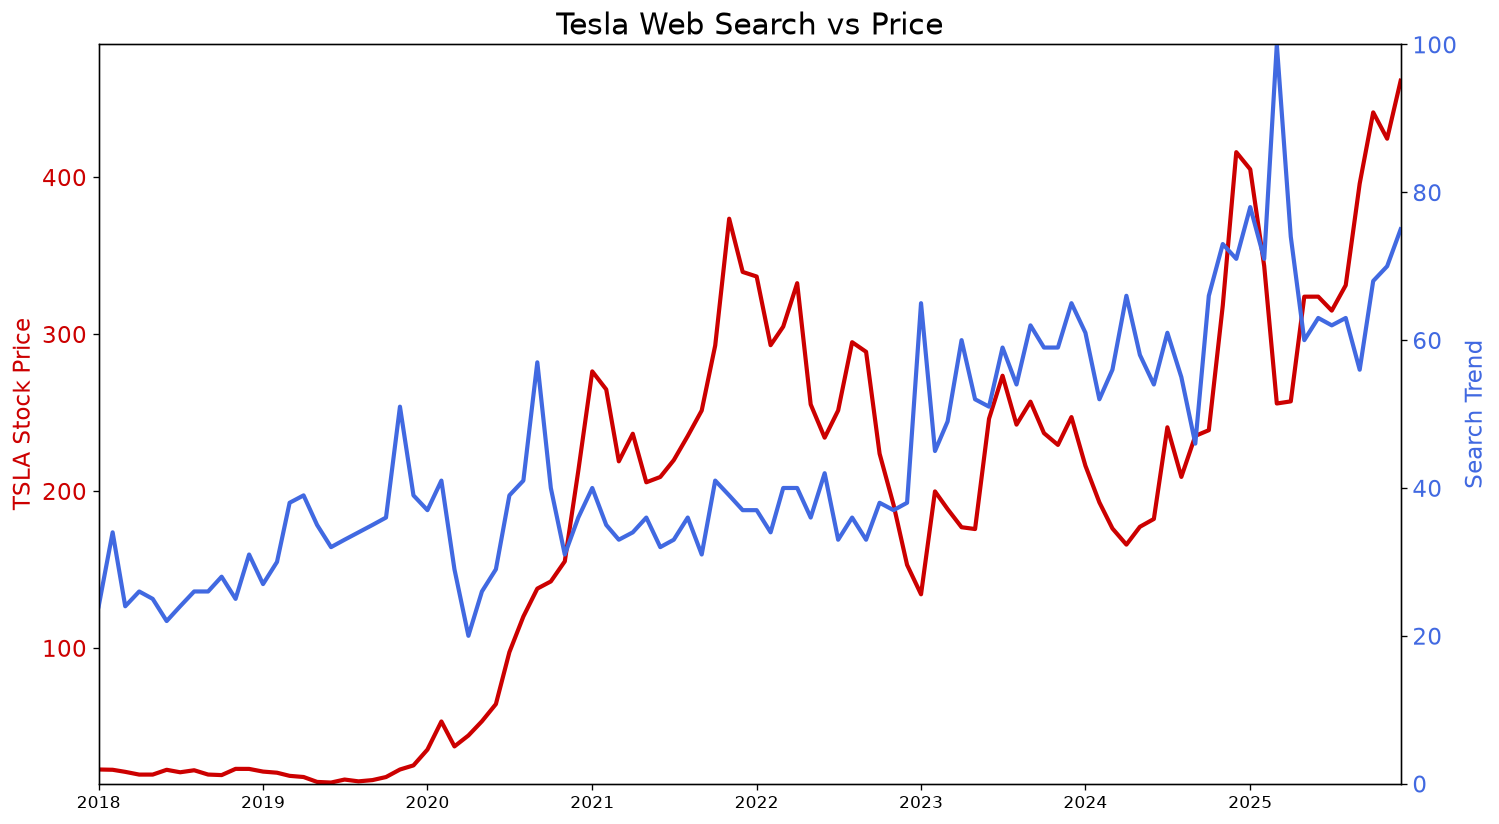

In [46]:
plt.figure(figsize=(14, 8), dpi=120) # Figure size + DPI
plt.title("Tesla Web Search vs Price", fontsize=18) # Title

# First axis (Stock Price)
ax1 = plt.gca()
ax1.plot(df_tesla["MONTH"], df_tesla["TSLA_USD_CLOSE"], color="#cc0000", linewidth=2.5, label="TSLA Stock Price")
ax1.set_ylabel("TSLA Stock Price", fontsize=14, color="#cc0000")
ax1.tick_params(axis="y", labelcolor="#cc0000", labelsize=14)

# Second axis (Search Trend)
ax2 = ax1.twinx()
ax2.plot(df_tesla["MONTH"], df_tesla["TESLA_NEWS_SEARCH_PT"], color="royalblue", linewidth=2.5, label="Search Trend")
ax2.set_ylabel("Search Trend", fontsize=14, color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue", labelsize=14)

plt.xticks(rotation=45, fontsize=14) # X-axis formatting

# Axis limits
ax1.set_ylim(df_tesla["TSLA_USD_CLOSE"].min() * 0.95, df_tesla["TSLA_USD_CLOSE"].max() * 1.05)
ax2.set_ylim(0, 100)
ax1.set_xlim(df_tesla["MONTH"].min(), df_tesla["MONTH"].max())
plt.show() # Show chart

### What can be observed:
- **2018–2019:** Tesla’s stock price was low, and search interest remained moderate.
- **2020:** Both lines rise sharply — this marks the start of Tesla’s major growth phase.
- **2021 onward:** The two trends move somewhat together; when public interest spikes, the stock price often climbs too.
- **2025:** Both reach new highs, suggesting strong market enthusiasm and public attention.

In short, the chart suggests a **positive correlation** — when people search more about Tesla, its stock price tends to be higher.

### Bitcoin (BTC) Price v.s. Search Volume

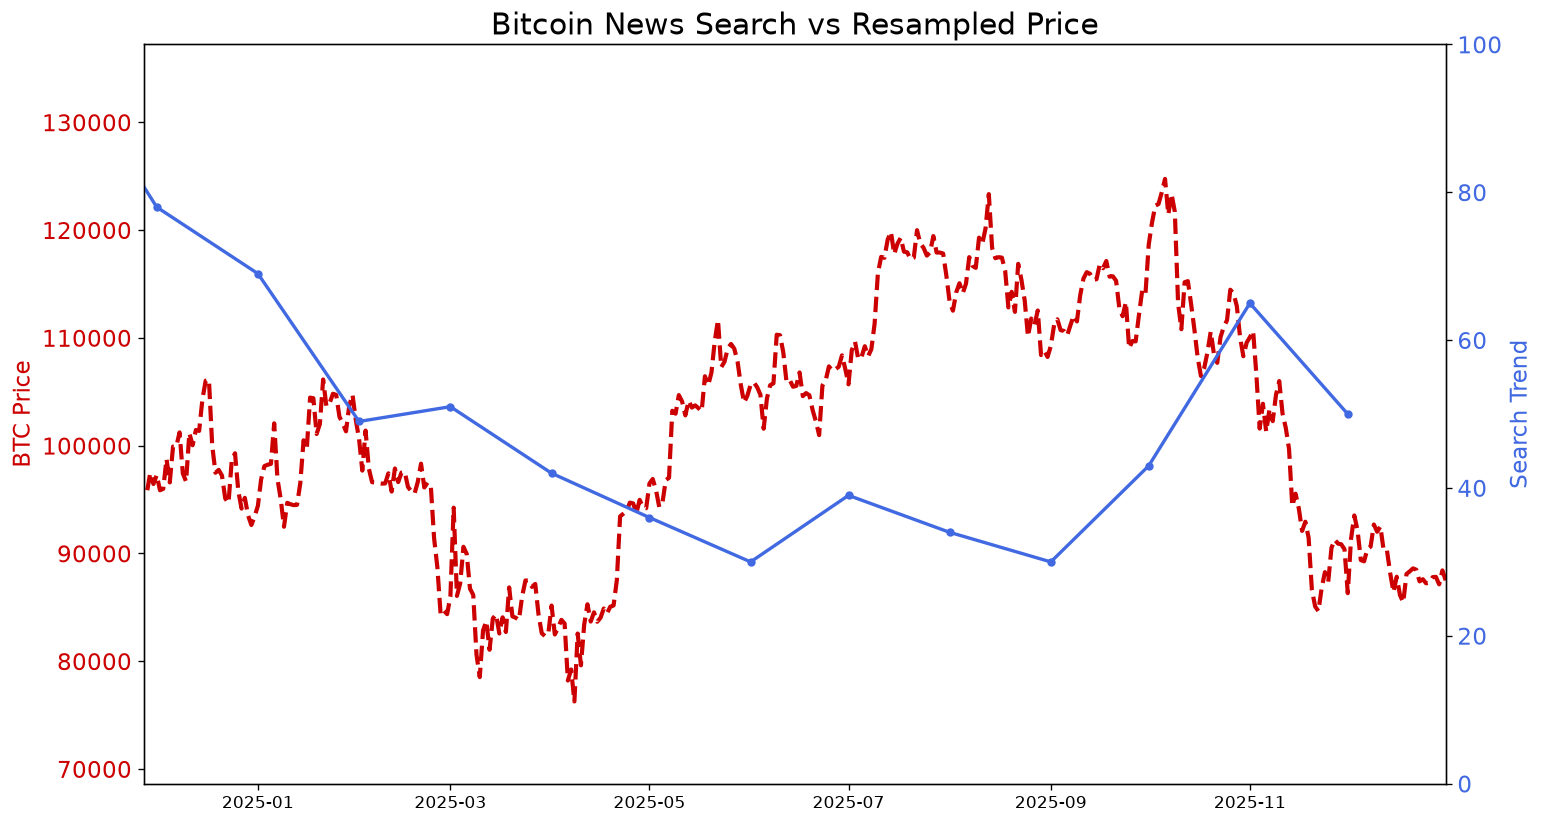

In [51]:
plt.figure(figsize=(14, 8), dpi=120)

# First axis: BTC Price (dashed line)
ax1 = plt.gca()
ax1.plot(df_btc_price["DATE"], df_btc_price["CLOSE"],color="#cc0000", linestyle="--", linewidth=2.5, label="BTC Price")
ax1.set_ylabel("BTC Price", fontsize=14, color="#cc0000")
ax1.tick_params(axis="y", labelcolor="#cc0000", labelsize=14)

# Second axis: Search Trend (circle markers)
ax2 = ax1.twinx()
ax2.plot(df_btc_search["MONTH"], df_btc_search["BTC_NEWS_SEARCH_PT"],color="royalblue", marker="o", markersize=4, linewidth=2,label="Search Trend")
ax2.set_ylabel("Search Trend", fontsize=14, color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue", labelsize=14)

plt.xticks(rotation=45, fontsize=14) # X-axis formatting

plt.title("Bitcoin News Search vs Resampled Price", fontsize=18)# Title

# Axis limits
ax1.set_ylim(df_btc_price["CLOSE"].min() * 0.90,df_btc_price["CLOSE"].max() * 1.10)
ax2.set_ylim(0, 100)
ax1.set_xlim(df_btc_price["DATE"].min(),df_btc_price["DATE"].max())
plt.show()

Bitcoin’s price (red dashed line) and search interest (blue line) move roughly together through 2025.

- **Early 2025:** Both start high, then fall sharply.
- **Mid‑2025:** The price rebounds while searches stay low.
- **Late 2025:** Search interest spikes again, followed by another price drop.

Overall, big search surges often coincide with major price swings, showing a **loose positive correlation** between public attention and Bitcoin’s market moves.

### Unemployement Benefits Search vs. Actual Unemployment in the Portugal

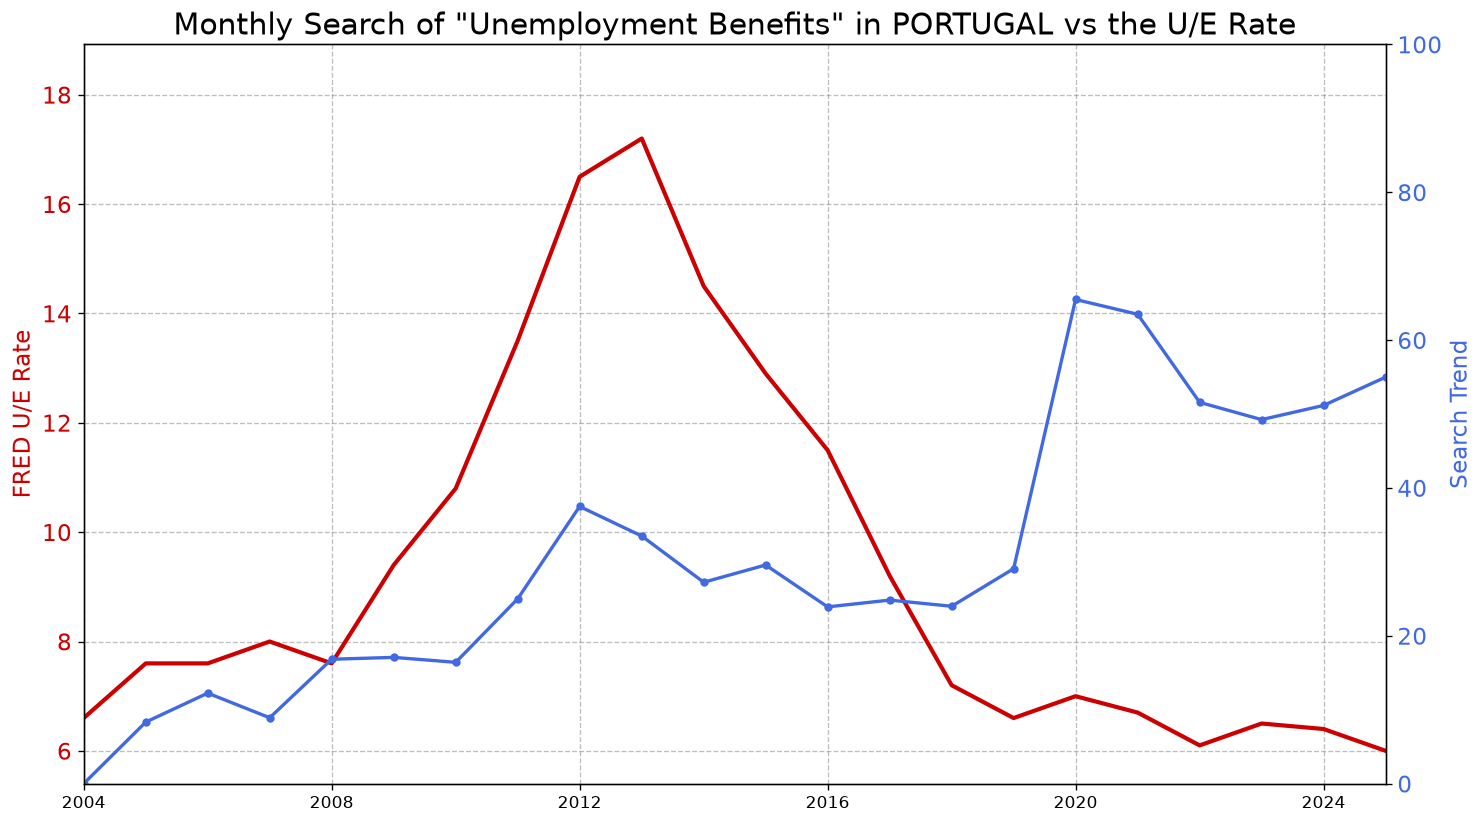

In [53]:
plt.figure(figsize=(14, 8), dpi=120)

# First axis: Unemployment Rate (FRED)
ax1 = plt.gca()
ax1.plot(df_unemployment["YEAR"], df_unemployment["UNRATE_PT"],color="#cc0000", linewidth=2.5, label="U/E Rate")
ax1.set_ylabel("FRED U/E Rate", fontsize=14, color="#cc0000")
ax1.tick_params(axis="y", labelcolor="#cc0000", labelsize=14)

# Second axis: Search Trend (circle markers)
ax2 = ax1.twinx()
ax2.plot(df_unemployment["YEAR"], df_unemployment["UE_BENEFITS_WEB_SEARCH_PT"],color="royalblue", marker="o", markersize=4, linewidth=2,label="Search Trend")
ax2.set_ylabel("Search Trend", fontsize=14, color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue", labelsize=14)

plt.title('Monthly Search of "Unemployment Benefits" in PORTUGAL vs the U/E Rate',fontsize=18)# Title

plt.xticks(rotation=45, fontsize=14)# X-axis formatting

# Axis limits
ax1.set_ylim(df_unemployment["UNRATE_PT"].min() * 0.9,df_unemployment["UNRATE_PT"].max() * 1.1)
ax2.set_ylim(0, 100)
ax1.set_xlim(df_unemployment["YEAR"].min(),df_unemployment["YEAR"].max())
ax1.grid(True, linestyle="--", color="grey", alpha=0.5) # Grey dashed grid
plt.show()

The chart shows that **search interest for “unemployment benefits” in Portugal rises when unemployment increases**.

- **2008–2013:** Both unemployment and searches peak during the financial crisis.
- **2020:** Another spike appears with the COVID‑19 pandemic.
- **After 2021:** Both indicators stabilize at lower levels.

There’s **no strong seasonality** — searches mainly respond to **economic crises**, not recurring yearly patterns.